In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas'

In [3]:
df = pd.read_parquet("normalization.parquet")

NameError: name 'pd' is not defined

In [7]:
anon_il = [
    462,
    632,
    635,
    636,
    638,
    639,
    641,
    642,
    644,
    645,
    647,
    2852,
]  # changed 982 to 2852
anon_oh = [127, 187, 221, 228, 255, 273, 276, 277, 36, 374, 398, 442]

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=False)
axes = axes.flatten()

for ax, plant in zip(axes, anon_il):
    sub = df[df["wwtp_name_id"] == plant].sort_values("sample_collect_date")

    if plant == 635:
        sub = sub[sub["flowpop"] > 0]

    ords = sub["sample_collect_date"].map(pd.Timestamp.toordinal)

    ax.plot(ords, sub["conc"], label="conc")
    ax.plot(ords, sub["flowpop"], label="flowpop")

    ax.scatter(ords, sub["conc"], marker="o")
    ax.scatter(ords, sub["flowpop"], marker="s")

    tick_positions = np.linspace(ords.min(), ords.max(), 6)
    tick_positions = tick_positions.astype(int)

    tick_labels = [
        pd.Timestamp.fromordinal(int(t)).strftime("%Y-%m-%d")
        for t in tick_positions
    ]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")

    ax.set_title(f"Site: {plant}")

fig.text(
    0.04,
    0.5,
    "log concentration)",
    va="center",
    rotation="vertical",
    fontsize=32,
)

plt.tight_layout(rect=[0.06, 0, 1, 1])

plt.legend()

plt.savefig("il.png", bbox_inches="tight")

plt.show()

NameError: name 'plt' is not defined

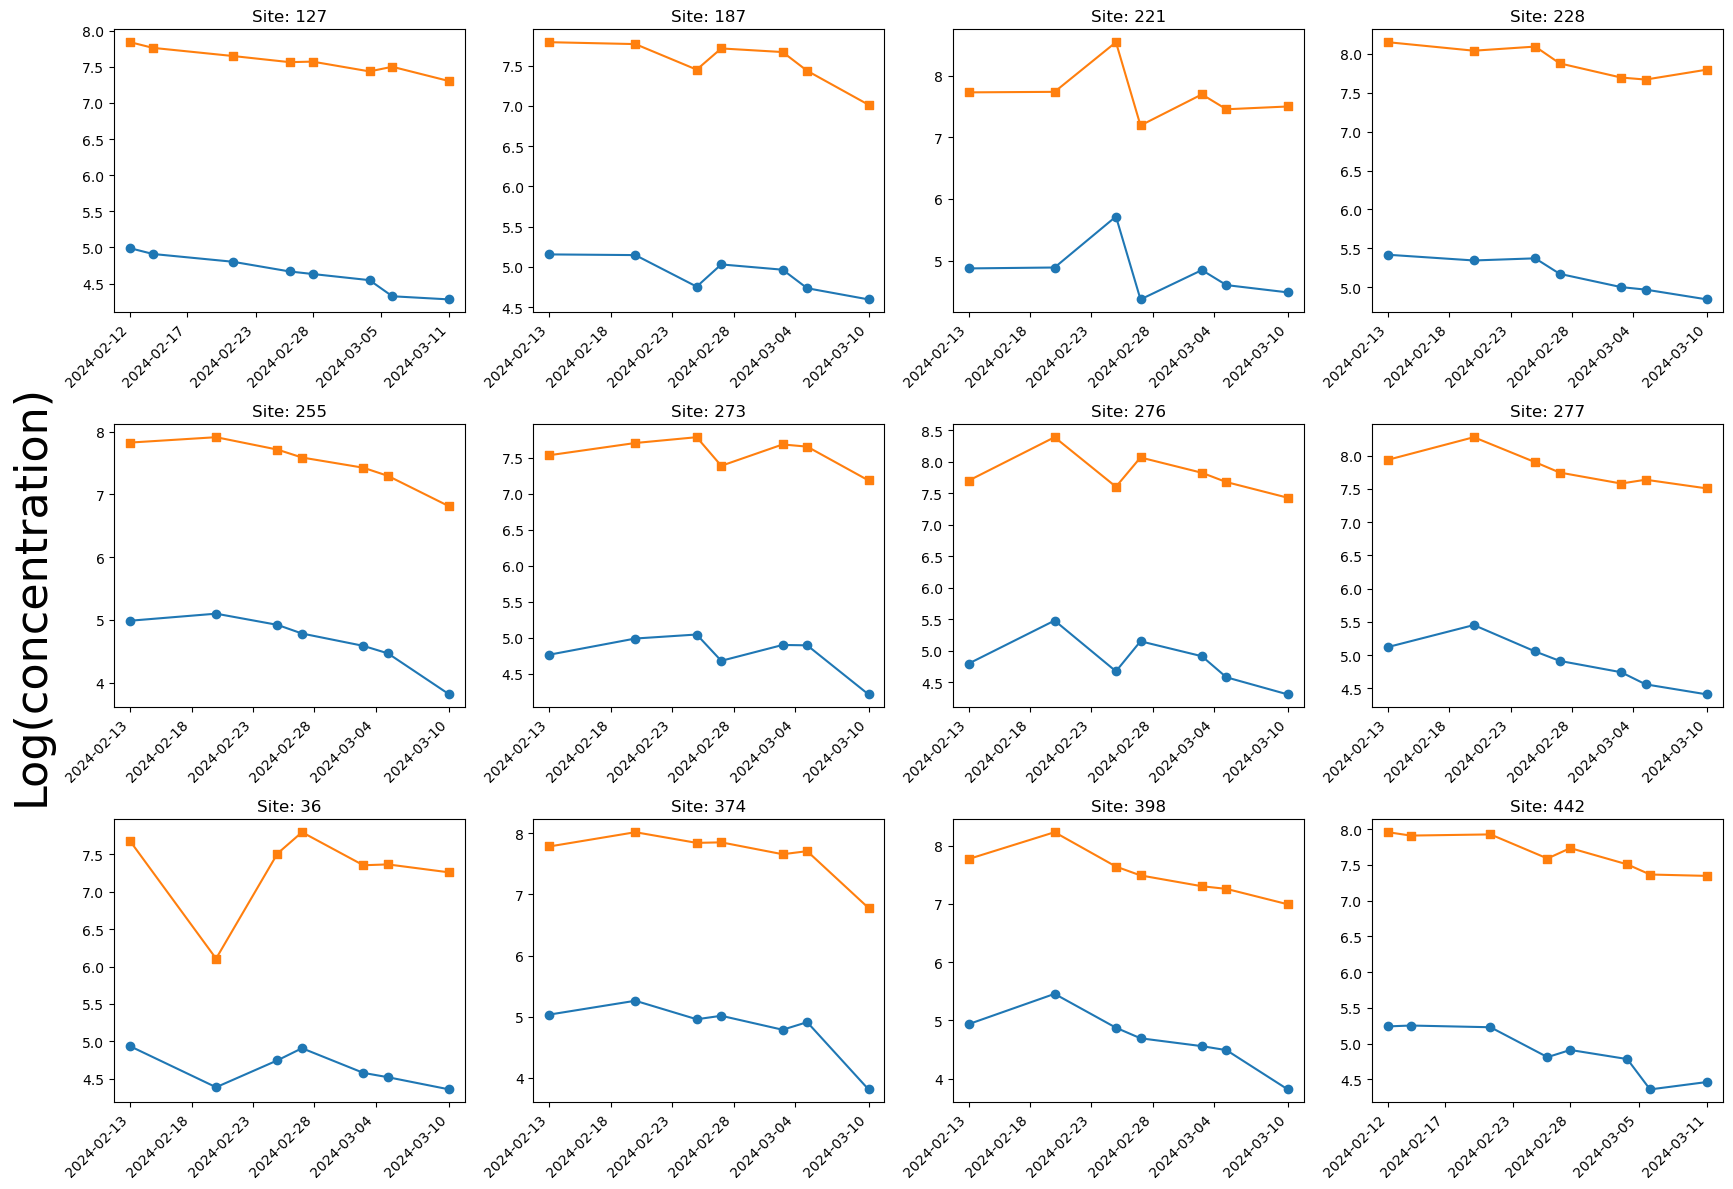

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12), sharex=False)
axes = axes.flatten()

for ax, plant in zip(axes, anon_oh):
    sub = df[df["wwtp_name_id"] == plant].sort_values("sample_collect_date")

    if plant == 36:
        sub = sub[sub["flowpop"] > 0]

    ords = sub["sample_collect_date"].map(pd.Timestamp.toordinal)

    ax.plot(ords, sub["conc"], label="conc")
    ax.plot(ords, sub["flowpop"], label="flowpop")

    ax.scatter(ords, sub["conc"], marker="o")
    ax.scatter(ords, sub["flowpop"], marker="s")

    tick_positions = np.linspace(ords.min(), ords.max(), 6)
    tick_positions = tick_positions.astype(int)

    tick_labels = [
        pd.Timestamp.fromordinal(int(t)).strftime("%Y-%m-%d")
        for t in tick_positions
    ]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")

    ax.set_title(f"Site: {plant}")

fig.text(
    0.04,
    0.5,
    "Log(concentration)",
    va="center",
    rotation="vertical",
    fontsize=32,
)

plt.tight_layout(rect=[0.06, 0, 1, 1])

plt.savefig("oh.png", bbox_inches="tight")

plt.show()